# Model met 6 features

Hier is eerste ontwerp van van het model waarbij we maar 3 features gebruiken, we hebben deze 3 features gekozen:

stm_prioriteit: Dit is de prioriteitsindicatie, dat zegt hoe belangrijk het is dat deze storing snel opgelost moet worden.   
stm_oorz_code: Dit is de oorzaak code, dat geeft aan wat de oorzaak is van de storing.   
stm_sap_meldtijd: Dit is de meldtijd, dat zegt hoelaat de melding is gemaakt.   
stm_aann_t_fh: Dit is onze zelf aangemaakte target variabele, dit is de duur van wanneer de aannemer op locatie is, tot de treinen weer rijden.

stm_contractgeb_gst: Contractgebied van de aannemer   
stm_geo_mld: geocode van de melding    
stm_progfh_in_duur: Duur van hoelang het volgens de aannemer duurt om het probleem op te lossen.   


Om de target variabele te berekenen gebruiken we deze features:   
stm_aanntpl_dd: Datum wanneer aannemer op locatie is.    
stm_aanntpl_tijd: Tijd wanneer aannemer op locatie is.    
stm_fh_dd: Datum wanneer treinen weer rijden.    
stm_fh_tijd: Tijd waneer treinen weer rijden.   

Dit zijn de meetniveaus van de target en features:

stm_prioriteit: ordinaal   
stm_oorz_code: nominaal      
stm_sap_meldtijd: continu  
stm_aann_t_fh: continu    

stm_contractgeb_gst: nominaal   
stm_geo_mld: nominaal   
stm_progfh_in_duur: continu    

stm_aanntpl_dd: continu    
stm_aanntpl_tijd: continu     
stm_fh_dd: continu     
stm_fh_tijd: continu  

Onderzoeksvraag: Kunnen wij met 3 features al een redelijk model maken die kan voorspellen hoelang het duurt voordat de treinen weer rijden. 
Omdat we nu 2 extra nominale waardes hebben, gaan we gebruik maken van Gradient Boosting Regressor. Hiervoor hoeven we niet get_dummies te gebruiken, dus krijgen we uiteindelijk niet 1000 rijen.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import r2_score
import pickle
from datetime import datetime
from sklearn.metrics import mean_squared_error

In [2]:
df = pd.read_csv("sap_storing_data_hu_project.csv", low_memory=False)

## Data verifiëren, omzetten en maken
Eerst kijken we of er duplicates in de dataset zitten

In [3]:
df["#stm_sap_meldnr"].duplicated().sum()

332045

Er zitten 298799 duplicates in, deze gaan we verwijderen

In [4]:
df = df.drop_duplicates(subset=["#stm_sap_meldnr"])

### stm_prioriteit
Nu willen we gaan checken of we de features kunnen vertrouwen. Bij de stm_prioriteit kunnen we uit meegegeven documenten bepalen dat deze feature tussen de 1.0 en 9.0 in hele getallen loopt. Om dat te checken gebruiken we deze staafdiagram:

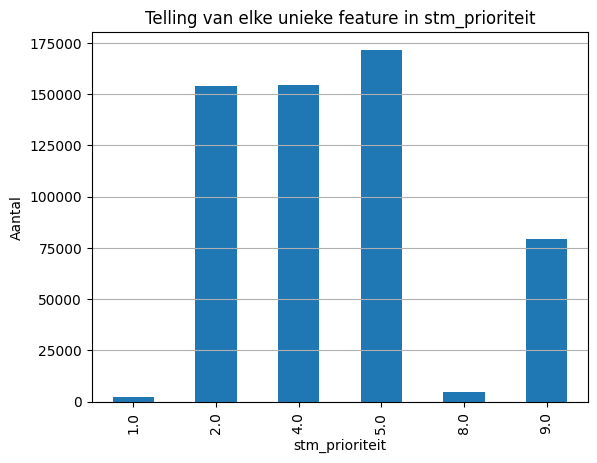

In [5]:
df['stm_prioriteit'].value_counts().sort_index().plot(kind='bar')

plt.title('Telling van elke unieke feature in stm_prioriteit')
plt.xlabel('stm_prioriteit')
plt.ylabel('Aantal')
plt.grid(axis='y')

Hier kunnen we zien dat wat in het megegeven document staat klopt, en er zitten geen values tussen, dus de data uit deze feature kunnen we vertrouwen. Ook hoeven we deze data niet om te zetten, omdat deze ordinaal is. 

Wat we well moeten doen is alle rijen verwijderen die prioriteit als 9.0 hebben. Deze betekenen dat er geen aannemer naar toe hoeft. Dus is er geen lang genoege storing om dit in de dataset te houden.

In [6]:
df = df[~df["stm_prioriteit"].isin([9.0])]
df["stm_prioriteit"].describe()

count    487039.000000
mean          3.741719
std           1.319368
min           1.000000
25%           2.000000
50%           4.000000
75%           5.000000
max           8.000000
Name: stm_prioriteit, dtype: float64

De max is nu 8.0, dit betekent dat alle rijen met prioriteit als 9.0 verwijderd zijn.

### stm_oorz_code
Bij de stm_oorz_code kunnen ook uit een meegegeven document vaststellen wat de verschillende oorzaak codes zijn. Om te kijken of er niet rare values in de kolom zitten, zullen we alle unieke values uit stm_oorz_code	halen, en handmatig checken of die allemaal in het document staan.

In [7]:
df = df.dropna(subset=["stm_prioriteit", "stm_oorz_code", "stm_sap_meldtijd", "stm_contractgeb_gst", "stm_geo_mld", "stm_progfh_in_duur"])
data = df[["stm_prioriteit", "stm_oorz_code", "stm_sap_meldtijd", "stm_contractgeb_gst", "stm_geo_mld", "stm_progfh_in_duur"]]
print(set(list(data["stm_oorz_code"])))

{130.0, 131.0, 132.0, 133.0, 134.0, 135.0, 136.0, 139.0, 140.0, 141.0, 142.0, 143.0, 144.0, 145.0, 146.0, 147.0, 148.0, 149.0, 150.0, 151.0, 154.0, 33.0, 294.0, 298.0, 299.0, 48.0, 51.0, 180.0, 181.0, 182.0, 183.0, 184.0, 185.0, 186.0, 187.0, 188.0, 189.0, 201.0, 202.0, 203.0, 204.0, 205.0, 206.0, 207.0, 208.0, 209.0, 210.0, 211.0, 212.0, 213.0, 214.0, 215.0, 218.0, 219.0, 220.0, 221.0, 222.0, 223.0, 224.0, 225.0, 226.0, 227.0, 228.0, 229.0, 230.0, 999.0, 231.0, 233.0, 234.0, 235.0, 239.0, 240.0, 241.0, 242.0, 250.0}


De volgende values uit die lijst die niet in het document staan zijn: 33, 48, 51 en 999, deze gaan we onderzoeken waarom deze in de dataset staan

In [8]:
data["stm_oorz_code"].value_counts().loc[[33.0, 48.0, 51.0, 999.0]]

stm_oorz_code
33.0       1
48.0       1
51.0       1
999.0    101
Name: count, dtype: int64

Nu zien we dat 33, 48 en 51 allemaal 1 keer voorkomen, deze zijn dus fouten in de dataset. Deze gaan we verwijderen.
999 komt 102 keer voor, dit is een typische waarde die wordt ingevoerd als de orzaakscode niet duidelijk is. Deze verwijderen we ook.

In [9]:
data = data[~data["stm_oorz_code"].isin([33.0, 48.0, 51.0, 999.0])]
data["stm_oorz_code"].describe()

count    451393.000000
mean        202.010966
std          46.809360
min         130.000000
25%         150.000000
50%         215.000000
75%         221.000000
max         299.000000
Name: stm_oorz_code, dtype: float64

We kunnen nu zien dat de min en max van stm_oorz_code valt binnen de values in het meegegeven document.

### stm_sap_meldtijd
Bij stm_sap_meldtijd kunnen we valse tijden hebben, die staan dan als "::" zoals hieronder te zien is. Deze gaan we verwijderen: 

In [10]:
len(data[data["stm_sap_meldtijd"] == "::"])

58

In [11]:
# Verwijderen door alles te verwijderen wat niet lengte 8 is, wat de lengte van de format van de tijd is. (14:00:00)
data = data.dropna(subset=["stm_sap_meldtijd"])
data = data[data["stm_sap_meldtijd"].apply(lambda x: len(x) == 8)]

Omdat de values in deze feature als string staan, moeten we deze omzetten naar een float. Daarom zetten we de stm_sap_meldtijd om naar minuten. Dit zijn dus hoeveel minuten er op dag voorbij zijn gegaan sinds middennacht.

In [12]:
for index, i in data["stm_sap_meldtijd"].items():
    time_lst = i.split(":") 
    time_in_min = float(time_lst[0]) * 60 + float(time_lst[1]) + float(time_lst[2]) / 60
    data.at[index, "stm_sap_meldtijd"] = time_in_min

In [13]:
data["stm_sap_meldtijd"] = pd.to_numeric(data["stm_sap_meldtijd"])

data["stm_sap_meldtijd"].describe()

count    451335.000000
mean        757.624667
std         335.607815
min           0.000000
25%         527.000000
50%         750.000000
75%         999.000000
max        1439.983333
Name: stm_sap_meldtijd, dtype: float64

### stm_aann_t_fh
Alle tijden staan nu in minuten, nu gaan we de target aanmaken 

In [14]:
df1 = df[["stm_aanntpl_dd", "stm_aanntpl_tijd", "stm_fh_dd", "stm_fh_tijd"]].dropna()

# errors='coerce' om alle foute tijden om te zettten naar NaN
df1["stm_aanntpl_dd"] = pd.to_datetime(df1["stm_aanntpl_dd"], format="%d/%m/%Y", errors='coerce')
df1["stm_fh_dd"] = pd.to_datetime(df1["stm_fh_dd"], format="%d/%m/%Y", errors='coerce')

df1["stm_fh_tijd"] = pd.to_datetime(df1["stm_fh_tijd"], format="%H:%M:%S", errors='coerce')
df1["stm_aanntpl_tijd"] = pd.to_datetime(df1["stm_aanntpl_tijd"], format="%H:%M:%S", errors='coerce')

dagen_verschil = ((df1["stm_fh_dd"] - df1["stm_aanntpl_dd"]).dt.days) * 24 * 60
tijden_verschil = (df1["stm_fh_tijd"] - df1["stm_aanntpl_tijd"]).dt.total_seconds() / 60

data["stm_aann_t_fh"] = dagen_verschil + tijden_verschil

# Verwijder alle foute tijden die naar NaN zijn omgezet
data = data.dropna(subset=["stm_aann_t_fh"])

data[["stm_prioriteit", "stm_aann_t_fh", "stm_sap_meldtijd"]].describe()

,stm_prioriteit,stm_aann_t_fh,stm_sap_meldtijd
count,417213.000000,4.172130e+05,417213.000000
mean,3.689159,4.755836e+02,755.231857
std,1.350328,1.083829e+04,335.081938
min,1.000000,-1.167949e+05,0.000000
25%,2.000000,1.005000e+01,526.000000
50%,4.000000,3.200000e+01,747.000000
75%,5.000000,7.600000e+01,995.000000
max,8.000000,4.211280e+06,1439.983333


In [15]:
data["stm_aann_t_fh"].describe()

count    4.172130e+05
mean     4.755836e+02
std      1.083829e+04
min     -1.167949e+05
25%      1.005000e+01
50%      3.200000e+01
75%      7.600000e+01
max      4.211280e+06
Name: stm_aann_t_fh, dtype: float64

Zoals we zien is de max heel hoog en is de min een min getal, uit het interview hebben we de tips gekregen om alles onder de 5 minuten en boven de 8 uur weg te halen.

In [16]:
data = data[data["stm_aann_t_fh"] <= (8 * 60)] # 8 uur
data = data[data["stm_aann_t_fh"] >= 5] # 5 minuten
data[["stm_prioriteit", "stm_aann_t_fh", "stm_sap_meldtijd"]].describe()

,stm_prioriteit,stm_aann_t_fh,stm_sap_meldtijd
count,334169.000000,334169.000000,334169.000000
mean,3.682690,66.687183,752.867623
std,1.357688,73.909008,335.838493
min,1.000000,5.000000,0.000000
25%,2.000000,20.000000,522.000000
50%,4.000000,41.000000,743.000000
75%,5.000000,83.000000,995.000000
max,8.000000,480.000000,1439.983333


### stm_contractgeb_gst

In [17]:
print(set(list(data["stm_contractgeb_gst"])))

{1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, 26.0, 27.0, 28.0, 29.0, 30.0, 31.0, 32.0, 33.0, 34.0, 35.0, 36.0, 37.0, 50.0, 51.0, 52.0, 53.0, 54.0, 55.0, 56.0, 57.0, 58.0, 59.0, 60.0, 61.0, 62.0, 63.0, 64.0, 70.0, 71.0, 81.0, 82.0, 83.0, 99.0}


In [18]:
data["stm_contractgeb_gst"].value_counts().loc[[17.0, 50.0, 53.0, 54.0, 55.0, 56.0, 57.0, 62.0, 64.0, 82.0, 83.0]]

stm_contractgeb_gst
17.0    1370
50.0     126
53.0    7466
54.0    3034
55.0    2543
56.0    1287
57.0     196
62.0    4863
64.0    1910
82.0      68
83.0     401
Name: count, dtype: int64

Ookal staan deze geocodes niet in de dataset, gaan we ze nog steeds houden. Dit doen we omdat van elke geocode die niet in de dataset, er nog steeds een hoop van zijn; er zijn dus geen type fouten

Uit het meegegeven document kunnen we vastellen dat 63, 61, 51, 52, 60, 58, 59 en 70 onbekend zijn. Deze gaan we eerst onderzoeken.

In [19]:
data["stm_contractgeb_gst"].value_counts().loc[[63, 61, 51, 52, 60, 58, 59, 70]]

stm_contractgeb_gst
63.0    2627
61.0    3802
51.0    5465
52.0    4182
60.0    1574
58.0    3284
59.0    2744
70.0      68
Name: count, dtype: int64

Hier zien we dat de onbekende geocodes wel veel waardes hebben, deze hoeven we dus niet te verwijderen.

### stm_geo_mld
Bij stm_geo_mld willen we ook kijken of er verkeerde geocodes in de dataset zitten

In [20]:
print(sorted(set(data["stm_geo_mld"])))

['001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '015', '016', '017', '018', '020', '021', '022', '023', '024', '025', '026', '027', '028', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '046', '047', '049', '050', '051', '052', '053', '054', '055', '056', '057', '058', '059', '060', '062', '063', '064', '067', '070', '071', '072', '073', '074', '075', '076', '078', '079', '080', '082', '083', '084', '085', '087', '089', '090', '091', '092', '093', '094', '095', '096', '097', '098', '099', '1', '1.0', '10', '10.0', '100', '100.0', '101', '101.0', '102', '102.0', '103', '103.0', '104', '104.0', '105', '105.0', '106', '107', '107.0', '108', '108.0', '109', '109.0', '11', '11.0', '110', '110.0', '111', '111.0', '112', '112.0', '114', '114.0', '115', '115.0', '116', '116.0', '117', '117.0', '118', '118.0', '119', '119.0', '12', '12.0', '120', '120.0', '121', '121.0', '122', '122.0', '123', 

We kunnen zien dat er ontzetten veel verkeerde waardes in zitten. We zien dat er een float en int versie is van veel geo codes, deze willen we hetzelfde maken

In [21]:
data['stm_geo_mld'] = data['stm_geo_mld'].astype(float).astype(int)
data['stm_geo_mld'] 

95714     119
139811     63
139813    557
139814    817
139816     62
         ... 
898510    155
898516    118
898520    560
898522    468
898524    102
Name: stm_geo_mld, Length: 334169, dtype: int32

Nu kunnen we zien dat alle values int32 zijn, nu kunnen we gaan kijken of er nog verkeerde geocodes in staan

In [22]:
print(dict(data["stm_geo_mld"].value_counts()))

{586: 12817, 531: 11571, 950: 9505, 924: 8768, 603: 7380, 555: 7245, 506: 7000, 618: 6689, 133: 5343, 508: 5258, 127: 4496, 545: 3990, 17: 3956, 135: 3863, 520: 3815, 620: 3406, 116: 3145, 501: 3127, 55: 3067, 9: 2984, 47: 2859, 54: 2846, 112: 2684, 118: 2634, 564: 2632, 212: 2550, 517: 2529, 609: 2341, 560: 2217, 527: 2201, 73: 2097, 543: 2036, 87: 2035, 534: 2035, 503: 2018, 542: 2013, 158: 1905, 514: 1902, 203: 1890, 614: 1886, 123: 1884, 523: 1881, 2: 1853, 62: 1822, 117: 1817, 80: 1814, 115: 1797, 128: 1795, 478: 1767, 550: 1749, 35: 1742, 152: 1730, 79: 1706, 163: 1698, 12: 1688, 63: 1672, 120: 1578, 132: 1571, 85: 1555, 927: 1554, 57: 1541, 206: 1540, 525: 1529, 544: 1525, 504: 1493, 52: 1492, 105: 1476, 107: 1444, 8: 1430, 24: 1429, 625: 1419, 553: 1414, 31: 1402, 144: 1387, 624: 1372, 536: 1370, 217: 1325, 210: 1294, 139: 1292, 28: 1283, 528: 1277, 25: 1250, 76: 1248, 21: 1232, 664: 1231, 46: 1205, 78: 1197, 486: 1172, 535: 1168, 70: 1136, 551: 1135, 817: 1133, 513: 1115, 103:

Nu zien we dat er van veel geocodes er maar heel weinig van in de database staan. Daarom halen we alle geocodes weg waar er minder dan 5 in de dataset staan.

In [23]:
data = data[~data["stm_geo_mld"].isin({81, 816, 853, 77, 777, 850, 48, 939, 435, 843, 400, 921, 68, 910, 781, 902, 432, 834, 428, 858})]
data["stm_geo_mld"]

95714     119
139811     63
139813    557
139814    817
139816     62
         ... 
898510    155
898516    118
898520    560
898522    468
898524    102
Name: stm_geo_mld, Length: 334127, dtype: int32

### stm_progfh_in_duur

In [27]:
data["stm_progfh_in_duur"] = pd.to_numeric(data["stm_progfh_in_duur"], errors="coerce")

data = data[data["stm_progfh_in_duur"] <= (8 * 60)] # 8 uur
data = data[data["stm_progfh_in_duur"] >= 5] # 5 minuten

data[["stm_aann_t_fh", "stm_progfh_in_duur"]].corr()
# Haal nog met de tijd wanneer prognose is ingevoerd als die later dan de functiehersteltijd is, weggooien.

,stm_aann_t_fh,stm_progfh_in_duur
stm_aann_t_fh,1.000000,0.687396
stm_progfh_in_duur,0.687396,1.000000


## Model

Als eerst maken we een baseline model met de mediaan en het gemiddelde:

In [25]:
median = data[["stm_aann_t_fh"]].median()

baseline = [median] * len(data)

print(f"R2 score: {r2_score(data['stm_aann_t_fh'], baseline)}")

RMSE = np.sqrt(mean_squared_error(data['stm_aann_t_fh'], baseline))
print(f"Root Mean Squared Error: {RMSE}")

baseline_info = {'baseline': baseline, 'rmse': RMSE}

with open('base_model.pkl', 'wb') as file:
    pickle.dump(baseline_info, file)

R2 score: -0.10792049652907298
Root Mean Squared Error: 74.22647207529832


Met een score Baseline van -0.10790995766242273, kunnen we vastellen dat het gemiddelde een betere manier is om de stm_aann_t_fh te voorspellen dan de mediaan. Dit kunnen we zeggen omdat de score Baseline een negatief getal is.

Nu maken we het officiele model

In [26]:
model = GradientBoostingRegressor()

target = data["stm_aann_t_fh"]
features = data.drop(columns=["stm_aann_t_fh"])
# Sorteer nog op datum / tijd
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=10)

X_train['stm_oorz_code'] = pd.Categorical(X_train['stm_oorz_code']).codes
X_test['stm_oorz_code'] = pd.Categorical(X_test['stm_oorz_code']).codes

X_train['stm_contractgeb_gst'] = pd.Categorical(X_train['stm_contractgeb_gst']).codes
X_test['stm_contractgeb_gst'] = pd.Categorical(X_test['stm_contractgeb_gst']).codes

X_train['stm_geo_mld'] = pd.Categorical(X_train['stm_geo_mld']).codes
X_test['stm_geo_mld'] = pd.Categorical(X_test['stm_geo_mld']).codes

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(f"R2 score: {r2_score(y_test, y_pred)}")

RMSE = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"Root Mean Square Error: {RMSE}")

model_info = {'model': model, 'rmse': RMSE}

with open('gradient_boosting_model.pkl', 'wb') as file:
    pickle.dump(model_info, file)

R2 score: 0.5208132146311812
Root Mean Square Error: 49.20896598165683


## Conclusie
Het model met 6 features met een r2 score van 0.5208132146311814 is niet goed genoeg om de target te voorspellen.